In [ ]:
import marimo as mo

#Problem Statement :- Increase the Fulfillment rate

## Exploring data

In [ ]:
import pandas as pd

# offers table 
offer = pd.read_csv("datasets/data_offers.csv")
offer

<marimo-table data-initial-value='[]' data-label='null' data-data='"[{\"order_gk\":3000579625629,\"offer_id\":300050936206},{\"order_gk\":3000627306450,\"offer_id\":300052064651},{\"order_gk\":3000632920686,\"offer_id\":300052408812},{\"order_gk\":3000632771725,\"offer_id\":300052393030},{\"order_gk\":3000583467642,\"offer_id\":300051001196},{\"order_gk\":3000589281354,\"offer_id\":300051262015},{\"order_gk\":3000589106142,\"offer_id\":300051250324},{\"order_gk\":3000622819913,\"offer_id\":300051794962},{\"order_gk\":3000630156692,\"offer_id\":300052288434},{\"order_gk\":3000630781485,\"offer_id\":300052318376}]"' data-total-rows='334363' data-total-columns='2' data-max-columns='50' data-banner-text='""' data-pagination='true' data-page-size='10' data-field-types='[["order_gk",["integer","int64"]],["offer_id",["integer","int64"]]]' data-show-filters='true' data-show-download='true' data-show-column-summaries='true' data-show-data-types='true' data-show-page-size-selector='true' data-show-column-explorer='true' data-show-chart-builder='true' data-row-headers='[]' data-has-stable-row-id='false' data-lazy='false' data-preload='false' data-download-file-name='"df"'>

In [ ]:
#orders table 

order = pd.read_csv("datasets/data_orders.csv")
order

<marimo-table data-initial-value='[]' data-label='null' data-data='"[{\"order_datetime\":\"18:08:07\",\"origin_longitude\":-0.978916,\"origin_latitude\":51.456173,\"m_order_eta\":60.0,\"order_gk\":3000583041974,\"order_status_key\":4,\"is_driver_assigned_key\":1,\"cancellations_time_in_seconds\":198.0},{\"order_datetime\":\"20:57:32\",\"origin_longitude\":-0.950385,\"origin_latitude\":51.456843,\"m_order_eta\":NaN,\"order_gk\":3000583116437,\"order_status_key\":4,\"is_driver_assigned_key\":0,\"cancellations_time_in_seconds\":128.0},{\"order_datetime\":\"12:07:50\",\"origin_longitude\":-0.96952,\"origin_latitude\":51.455544,\"m_order_eta\":477.0,\"order_gk\":3000582891479,\"order_status_key\":4,\"is_driver_assigned_key\":1,\"cancellations_time_in_seconds\":46.0},{\"order_datetime\":\"13:50:20\",\"origin_longitude\":-1.054671,\"origin_latitude\":51.460544,\"m_order_eta\":658.0,\"order_gk\":3000582941169,\"order_status_key\":4,\"is_driver_assigned_key\":1,\"cancellations_time_in_seconds\":62.0},{\"order_datetime\":\"21:24:45\",\"origin_longitude\":-0.967605,\"origin_latitude\":51.458236,\"m_order_eta\":NaN,\"order_gk\":3000583140877,\"order_status_key\":9,\"is_driver_assigned_key\":0,\"cancellations_time_in_seconds\":NaN},{\"order_datetime\":\"21:21:23\",\"origin_longitude\":-0.947011,\"origin_latitude\":51.45638,\"m_order_eta\":NaN,\"order_gk\":3000583117054,\"order_status_key\":9,\"is_driver_assigned_key\":0,\"cancellations_time_in_seconds\":NaN},{\"order_datetime\":\"07:58:15\",\"origin_longitude\":-0.955637,\"origin_latitude\":51.470372,\"m_order_eta\":NaN,\"order_gk\":3000582791789,\"order_status_key\":9,\"is_driver_assigned_key\":0,\"cancellations_time_in_seconds\":NaN},{\"order_datetime\":\"07:53:46\",\"origin_longitude\":-0.97823,\"origin_latitude\":51.454575,\"m_order_eta\":NaN,\"order_gk\":3000582791562,\"order_status_key\":9,\"is_driver_assigned_key\":0,\"cancellations_time_in_seconds\":NaN},{\"order_datetime\":\"08:53:01\",\"origin_longitude\":-1.052298,\"origin_latitude\":51.454308,\"m_order_eta\":NaN,\"order_gk\":3000582817606,\"order_status_key\":9,\"is_driver_assigned_key\":0,\"cancellations_time_in_seconds\":NaN},{\"order_datetime\":\"06:33:52\",\"origin_longitude\":-0.976216,\"origin_latitude\":51.433202,\"m_order_eta\":NaN,\"order_gk\":3000582765616,\"order_status_key\":4,\"is_driver_assigned_key\":0,\"cancellations_time_in_seconds\":78.0}]"' data-total-rows='10716' data-total-columns='8' data-max-columns='50' data-banner-text='""' data-pagination='true' data-page-size='10' data-field-types='[["order_datetime",["string","str"]],["origin_longitude",["number","float64"]],["origin_latitude",["number","float64"]],["m_order_eta",["number","float64"]],["order_gk",["integer","int64"]],["order_status_key",["integer","int64"]],["is_driver_assigned_key",["integer","int64"]],["cancellations_time_in_seconds",["number","float64"]]]' data-show-filters='true' data-show-download='true' data-show-column-summaries='true' data-show-data-types='true' data-show-page-size-selector='true' data-show-column-explorer='true' data-show-chart-builder='true' data-row-headers='[]' data-has-stable-row-id='false' data-lazy='false' data-preload='false' data-download-file-name='"df"'>

### checking whether different event logs are there for an order or not ?

In [ ]:
# Count duplicate order IDs
order['order_gk'].duplicated().sum()

np.int64(0)

#### no dupicate orders

### checking whether multiple offers are being applied to an order or not ?

In [ ]:
offer['order_gk'].duplicated().sum()

np.int64(236396)

#### As multiple offers have been applied to the orders and not needed for further analysis, threfore I am not joining it with orders

## Data Cleaning

### Improving Data Quality

#### the values in order_status_key and is_driver_assigned_key are not informative of the contents but are rather just keys that point to some internal description. We could replace their values with more informative information, like replacing the 1s in is_driver_assigned_key with the string Yes and the 0s with the string No. The same can be done for the order_status_key column

In [ ]:
import numpy as np


order['is_driver_assigned']=np.where(order['is_driver_assigned_key']==1,'yes','no')
order

<marimo-table data-initial-value='[]' data-label='null' data-data='"[{\"order_datetime\":\"18:08:07\",\"origin_longitude\":-0.978916,\"origin_latitude\":51.456173,\"m_order_eta\":60.0,\"order_gk\":3000583041974,\"order_status_key\":4,\"is_driver_assigned_key\":1,\"cancellations_time_in_seconds\":198.0,\"is_driver_assigned\":\"yes\"},{\"order_datetime\":\"20:57:32\",\"origin_longitude\":-0.950385,\"origin_latitude\":51.456843,\"m_order_eta\":NaN,\"order_gk\":3000583116437,\"order_status_key\":4,\"is_driver_assigned_key\":0,\"cancellations_time_in_seconds\":128.0,\"is_driver_assigned\":\"no\"},{\"order_datetime\":\"12:07:50\",\"origin_longitude\":-0.96952,\"origin_latitude\":51.455544,\"m_order_eta\":477.0,\"order_gk\":3000582891479,\"order_status_key\":4,\"is_driver_assigned_key\":1,\"cancellations_time_in_seconds\":46.0,\"is_driver_assigned\":\"yes\"},{\"order_datetime\":\"13:50:20\",\"origin_longitude\":-1.054671,\"origin_latitude\":51.460544,\"m_order_eta\":658.0,\"order_gk\":3000582941169,\"order_status_key\":4,\"is_driver_assigned_key\":1,\"cancellations_time_in_seconds\":62.0,\"is_driver_assigned\":\"yes\"},{\"order_datetime\":\"21:24:45\",\"origin_longitude\":-0.967605,\"origin_latitude\":51.458236,\"m_order_eta\":NaN,\"order_gk\":3000583140877,\"order_status_key\":9,\"is_driver_assigned_key\":0,\"cancellations_time_in_seconds\":NaN,\"is_driver_assigned\":\"no\"},{\"order_datetime\":\"21:21:23\",\"origin_longitude\":-0.947011,\"origin_latitude\":51.45638,\"m_order_eta\":NaN,\"order_gk\":3000583117054,\"order_status_key\":9,\"is_driver_assigned_key\":0,\"cancellations_time_in_seconds\":NaN,\"is_driver_assigned\":\"no\"},{\"order_datetime\":\"07:58:15\",\"origin_longitude\":-0.955637,\"origin_latitude\":51.470372,\"m_order_eta\":NaN,\"order_gk\":3000582791789,\"order_status_key\":9,\"is_driver_assigned_key\":0,\"cancellations_time_in_seconds\":NaN,\"is_driver_assigned\":\"no\"},{\"order_datetime\":\"07:53:46\",\"origin_longitude\":-0.97823,\"origin_latitude\":51.454575,\"m_order_eta\":NaN,\"order_gk\":3000582791562,\"order_status_key\":9,\"is_driver_assigned_key\":0,\"cancellations_time_in_seconds\":NaN,\"is_driver_assigned\":\"no\"},{\"order_datetime\":\"08:53:01\",\"origin_longitude\":-1.052298,\"origin_latitude\":51.454308,\"m_order_eta\":NaN,\"order_gk\":3000582817606,\"order_status_key\":9,\"is_driver_assigned_key\":0,\"cancellations_time_in_seconds\":NaN,\"is_driver_assigned\":\"no\"},{\"order_datetime\":\"06:33:52\",\"origin_longitude\":-0.976216,\"origin_latitude\":51.433202,\"m_order_eta\":NaN,\"order_gk\":3000582765616,\"order_status_key\":4,\"is_driver_assigned_key\":0,\"cancellations_time_in_seconds\":78.0,\"is_driver_assigned\":\"no\"}]"' data-total-rows='10716' data-total-columns='9' data-max-columns='50' data-banner-text='""' data-pagination='true' data-page-size='10' data-field-types='[["order_datetime",["string","str"]],["origin_longitude",["number","float64"]],["origin_latitude",["number","float64"]],["m_order_eta",["number","float64"]],["order_gk",["integer","int64"]],["order_status_key",["integer","int64"]],["is_driver_assigned_key",["integer","int64"]],["cancellations_time_in_seconds",["number","float64"]],["is_driver_assigned",["string","str"]]]' data-show-filters='true' data-show-download='true' data-show-column-summaries='true' data-show-data-types='true' data-show-page-size-selector='true' data-show-column-explorer='true' data-show-chart-builder='true' data-row-headers='[]' data-has-stable-row-id='false' data-lazy='false' data-preload='false' data-download-file-name='"df"'>

In [ ]:
order["order_status"] = np.where(order["order_status_key"] == 4, "Client Cancelled", "System Reject")
order

<marimo-table data-initial-value='[]' data-label='null' data-data='"[{\"order_datetime\":\"18:08:07\",\"origin_longitude\":-0.978916,\"origin_latitude\":51.456173,\"m_order_eta\":60.0,\"order_gk\":3000583041974,\"order_status_key\":4,\"is_driver_assigned_key\":1,\"cancellations_time_in_seconds\":198.0,\"is_driver_assigned\":\"yes\",\"order_status\":\"Client Cancelled\"},{\"order_datetime\":\"20:57:32\",\"origin_longitude\":-0.950385,\"origin_latitude\":51.456843,\"m_order_eta\":NaN,\"order_gk\":3000583116437,\"order_status_key\":4,\"is_driver_assigned_key\":0,\"cancellations_time_in_seconds\":128.0,\"is_driver_assigned\":\"no\",\"order_status\":\"Client Cancelled\"},{\"order_datetime\":\"12:07:50\",\"origin_longitude\":-0.96952,\"origin_latitude\":51.455544,\"m_order_eta\":477.0,\"order_gk\":3000582891479,\"order_status_key\":4,\"is_driver_assigned_key\":1,\"cancellations_time_in_seconds\":46.0,\"is_driver_assigned\":\"yes\",\"order_status\":\"Client Cancelled\"},{\"order_datetime\":\"13:50:20\",\"origin_longitude\":-1.054671,\"origin_latitude\":51.460544,\"m_order_eta\":658.0,\"order_gk\":3000582941169,\"order_status_key\":4,\"is_driver_assigned_key\":1,\"cancellations_time_in_seconds\":62.0,\"is_driver_assigned\":\"yes\",\"order_status\":\"Client Cancelled\"},{\"order_datetime\":\"21:24:45\",\"origin_longitude\":-0.967605,\"origin_latitude\":51.458236,\"m_order_eta\":NaN,\"order_gk\":3000583140877,\"order_status_key\":9,\"is_driver_assigned_key\":0,\"cancellations_time_in_seconds\":NaN,\"is_driver_assigned\":\"no\",\"order_status\":\"System Reject\"},{\"order_datetime\":\"21:21:23\",\"origin_longitude\":-0.947011,\"origin_latitude\":51.45638,\"m_order_eta\":NaN,\"order_gk\":3000583117054,\"order_status_key\":9,\"is_driver_assigned_key\":0,\"cancellations_time_in_seconds\":NaN,\"is_driver_assigned\":\"no\",\"order_status\":\"System Reject\"},{\"order_datetime\":\"07:58:15\",\"origin_longitude\":-0.955637,\"origin_latitude\":51.470372,\"m_order_eta\":NaN,\"order_gk\":3000582791789,\"order_status_key\":9,\"is_driver_assigned_key\":0,\"cancellations_time_in_seconds\":NaN,\"is_driver_assigned\":\"no\",\"order_status\":\"System Reject\"},{\"order_datetime\":\"07:53:46\",\"origin_longitude\":-0.97823,\"origin_latitude\":51.454575,\"m_order_eta\":NaN,\"order_gk\":3000582791562,\"order_status_key\":9,\"is_driver_assigned_key\":0,\"cancellations_time_in_seconds\":NaN,\"is_driver_assigned\":\"no\",\"order_status\":\"System Reject\"},{\"order_datetime\":\"08:53:01\",\"origin_longitude\":-1.052298,\"origin_latitude\":51.454308,\"m_order_eta\":NaN,\"order_gk\":3000582817606,\"order_status_key\":9,\"is_driver_assigned_key\":0,\"cancellations_time_in_seconds\":NaN,\"is_driver_assigned\":\"no\",\"order_status\":\"System Reject\"},{\"order_datetime\":\"06:33:52\",\"origin_longitude\":-0.976216,\"origin_latitude\":51.433202,\"m_order_eta\":NaN,\"order_gk\":3000582765616,\"order_status_key\":4,\"is_driver_assigned_key\":0,\"cancellations_time_in_seconds\":78.0,\"is_driver_assigned\":\"no\",\"order_status\":\"Client Cancelled\"}]"' data-total-rows='10716' data-total-columns='10' data-max-columns='50' data-banner-text='""' data-pagination='true' data-page-size='10' data-field-types='[["order_datetime",["string","str"]],["origin_longitude",["number","float64"]],["origin_latitude",["number","float64"]],["m_order_eta",["number","float64"]],["order_gk",["integer","int64"]],["order_status_key",["integer","int64"]],["is_driver_assigned_key",["integer","int64"]],["cancellations_time_in_seconds",["number","float64"]],["is_driver_assigned",["string","str"]],["order_status",["string","str"]]]' data-show-filters='true' data-show-download='true' data-show-column-summaries='true' data-show-data-types='true' data-show-page-size-selector='true' data-show-column-explorer='true' data-show-chart-builder='true' data-row-headers='[]' data-has-stable-row-id='false' data-lazy='false' data-preload='false' data-download-file-name='"df"'>

#### dropping irrelevant columns

In [ ]:
order.drop(columns=["is_driver_assigned_key", "order_status_key"], inplace=True)
order

<marimo-table data-initial-value='[]' data-label='null' data-data='"[{\"order_datetime\":\"18:08:07\",\"origin_longitude\":-0.978916,\"origin_latitude\":51.456173,\"m_order_eta\":60.0,\"order_gk\":3000583041974,\"cancellations_time_in_seconds\":198.0,\"is_driver_assigned\":\"yes\",\"order_status\":\"Client Cancelled\"},{\"order_datetime\":\"20:57:32\",\"origin_longitude\":-0.950385,\"origin_latitude\":51.456843,\"m_order_eta\":NaN,\"order_gk\":3000583116437,\"cancellations_time_in_seconds\":128.0,\"is_driver_assigned\":\"no\",\"order_status\":\"Client Cancelled\"},{\"order_datetime\":\"12:07:50\",\"origin_longitude\":-0.96952,\"origin_latitude\":51.455544,\"m_order_eta\":477.0,\"order_gk\":3000582891479,\"cancellations_time_in_seconds\":46.0,\"is_driver_assigned\":\"yes\",\"order_status\":\"Client Cancelled\"},{\"order_datetime\":\"13:50:20\",\"origin_longitude\":-1.054671,\"origin_latitude\":51.460544,\"m_order_eta\":658.0,\"order_gk\":3000582941169,\"cancellations_time_in_seconds\":62.0,\"is_driver_assigned\":\"yes\",\"order_status\":\"Client Cancelled\"},{\"order_datetime\":\"21:24:45\",\"origin_longitude\":-0.967605,\"origin_latitude\":51.458236,\"m_order_eta\":NaN,\"order_gk\":3000583140877,\"cancellations_time_in_seconds\":NaN,\"is_driver_assigned\":\"no\",\"order_status\":\"System Reject\"},{\"order_datetime\":\"21:21:23\",\"origin_longitude\":-0.947011,\"origin_latitude\":51.45638,\"m_order_eta\":NaN,\"order_gk\":3000583117054,\"cancellations_time_in_seconds\":NaN,\"is_driver_assigned\":\"no\",\"order_status\":\"System Reject\"},{\"order_datetime\":\"07:58:15\",\"origin_longitude\":-0.955637,\"origin_latitude\":51.470372,\"m_order_eta\":NaN,\"order_gk\":3000582791789,\"cancellations_time_in_seconds\":NaN,\"is_driver_assigned\":\"no\",\"order_status\":\"System Reject\"},{\"order_datetime\":\"07:53:46\",\"origin_longitude\":-0.97823,\"origin_latitude\":51.454575,\"m_order_eta\":NaN,\"order_gk\":3000582791562,\"cancellations_time_in_seconds\":NaN,\"is_driver_assigned\":\"no\",\"order_status\":\"System Reject\"},{\"order_datetime\":\"08:53:01\",\"origin_longitude\":-1.052298,\"origin_latitude\":51.454308,\"m_order_eta\":NaN,\"order_gk\":3000582817606,\"cancellations_time_in_seconds\":NaN,\"is_driver_assigned\":\"no\",\"order_status\":\"System Reject\"},{\"order_datetime\":\"06:33:52\",\"origin_longitude\":-0.976216,\"origin_latitude\":51.433202,\"m_order_eta\":NaN,\"order_gk\":3000582765616,\"cancellations_time_in_seconds\":78.0,\"is_driver_assigned\":\"no\",\"order_status\":\"Client Cancelled\"}]"' data-total-rows='10716' data-total-columns='8' data-max-columns='50' data-banner-text='""' data-pagination='true' data-page-size='10' data-field-types='[["order_datetime",["string","str"]],["origin_longitude",["number","float64"]],["origin_latitude",["number","float64"]],["m_order_eta",["number","float64"]],["order_gk",["integer","int64"]],["cancellations_time_in_seconds",["number","float64"]],["is_driver_assigned",["string","str"]],["order_status",["string","str"]]]' data-show-filters='true' data-show-download='true' data-show-column-summaries='true' data-show-data-types='true' data-show-page-size-selector='true' data-show-column-explorer='true' data-show-chart-builder='true' data-row-headers='[]' data-has-stable-row-id='false' data-lazy='false' data-preload='false' data-download-file-name='"df"'>

#### renaming date column

In [ ]:
rides = order.rename(columns={"order_datetime": "order_time"})

In [ ]:
rides

<marimo-table data-initial-value='[]' data-label='null' data-data='"[{\"order_time\":\"18:08:07\",\"origin_longitude\":-0.978916,\"origin_latitude\":51.456173,\"m_order_eta\":60.0,\"order_gk\":3000583041974,\"cancellations_time_in_seconds\":198.0,\"is_driver_assigned\":\"yes\",\"order_status\":\"Client Cancelled\"},{\"order_time\":\"20:57:32\",\"origin_longitude\":-0.950385,\"origin_latitude\":51.456843,\"m_order_eta\":NaN,\"order_gk\":3000583116437,\"cancellations_time_in_seconds\":128.0,\"is_driver_assigned\":\"no\",\"order_status\":\"Client Cancelled\"},{\"order_time\":\"12:07:50\",\"origin_longitude\":-0.96952,\"origin_latitude\":51.455544,\"m_order_eta\":477.0,\"order_gk\":3000582891479,\"cancellations_time_in_seconds\":46.0,\"is_driver_assigned\":\"yes\",\"order_status\":\"Client Cancelled\"},{\"order_time\":\"13:50:20\",\"origin_longitude\":-1.054671,\"origin_latitude\":51.460544,\"m_order_eta\":658.0,\"order_gk\":3000582941169,\"cancellations_time_in_seconds\":62.0,\"is_driver_assigned\":\"yes\",\"order_status\":\"Client Cancelled\"},{\"order_time\":\"21:24:45\",\"origin_longitude\":-0.967605,\"origin_latitude\":51.458236,\"m_order_eta\":NaN,\"order_gk\":3000583140877,\"cancellations_time_in_seconds\":NaN,\"is_driver_assigned\":\"no\",\"order_status\":\"System Reject\"},{\"order_time\":\"21:21:23\",\"origin_longitude\":-0.947011,\"origin_latitude\":51.45638,\"m_order_eta\":NaN,\"order_gk\":3000583117054,\"cancellations_time_in_seconds\":NaN,\"is_driver_assigned\":\"no\",\"order_status\":\"System Reject\"},{\"order_time\":\"07:58:15\",\"origin_longitude\":-0.955637,\"origin_latitude\":51.470372,\"m_order_eta\":NaN,\"order_gk\":3000582791789,\"cancellations_time_in_seconds\":NaN,\"is_driver_assigned\":\"no\",\"order_status\":\"System Reject\"},{\"order_time\":\"07:53:46\",\"origin_longitude\":-0.97823,\"origin_latitude\":51.454575,\"m_order_eta\":NaN,\"order_gk\":3000582791562,\"cancellations_time_in_seconds\":NaN,\"is_driver_assigned\":\"no\",\"order_status\":\"System Reject\"},{\"order_time\":\"08:53:01\",\"origin_longitude\":-1.052298,\"origin_latitude\":51.454308,\"m_order_eta\":NaN,\"order_gk\":3000582817606,\"cancellations_time_in_seconds\":NaN,\"is_driver_assigned\":\"no\",\"order_status\":\"System Reject\"},{\"order_time\":\"06:33:52\",\"origin_longitude\":-0.976216,\"origin_latitude\":51.433202,\"m_order_eta\":NaN,\"order_gk\":3000582765616,\"cancellations_time_in_seconds\":78.0,\"is_driver_assigned\":\"no\",\"order_status\":\"Client Cancelled\"}]"' data-total-rows='10716' data-total-columns='8' data-max-columns='50' data-banner-text='""' data-pagination='true' data-page-size='10' data-field-types='[["order_time",["string","str"]],["origin_longitude",["number","float64"]],["origin_latitude",["number","float64"]],["m_order_eta",["number","float64"]],["order_gk",["integer","int64"]],["cancellations_time_in_seconds",["number","float64"]],["is_driver_assigned",["string","str"]],["order_status",["string","str"]]]' data-show-filters='true' data-show-download='true' data-show-column-summaries='true' data-show-data-types='true' data-show-page-size-selector='true' data-show-column-explorer='true' data-show-chart-builder='true' data-row-headers='[]' data-has-stable-row-id='false' data-lazy='false' data-preload='false' data-download-file-name='"df"'>

##We are set for the analysis

### What are different types of cancellations?

In [ ]:
rides_cancelled=rides.pivot_table(columns=["is_driver_assigned", "order_status"], values="order_gk", aggfunc="count")
rides_cancelled

<marimo-table data-initial-value='[]' data-label='null' data-data='"[{\"\":\"order_gk\",\"no,Client Cancelled\":4496,\"no,System Reject\":3406,\"yes,Client Cancelled\":2811,\"yes,System Reject\":3}]"' data-total-rows='1' data-total-columns='4' data-max-columns='50' data-banner-text='""' data-pagination='true' data-page-size='10' data-field-types='[["no,Client Cancelled",["integer","int64"]],["no,System Reject",["integer","int64"]],["yes,Client Cancelled",["integer","int64"]],["yes,System Reject",["integer","int64"]]]' data-show-filters='true' data-show-download='true' data-show-column-summaries='false' data-show-data-types='true' data-show-page-size-selector='false' data-show-column-explorer='true' data-show-chart-builder='true' data-row-headers='[["",["string","str"]]]' data-has-stable-row-id='false' data-lazy='false' data-preload='false' data-download-file-name='"df"'>

#### a) A driver is assigned, then either the client or the sustem due to some issues at backend or due to some reason that this is not a valid loaction etc  gets rejected by the system

b) A driver is not assigned, wither the client gets cancelled or the system automatically rejects it due to supply issues

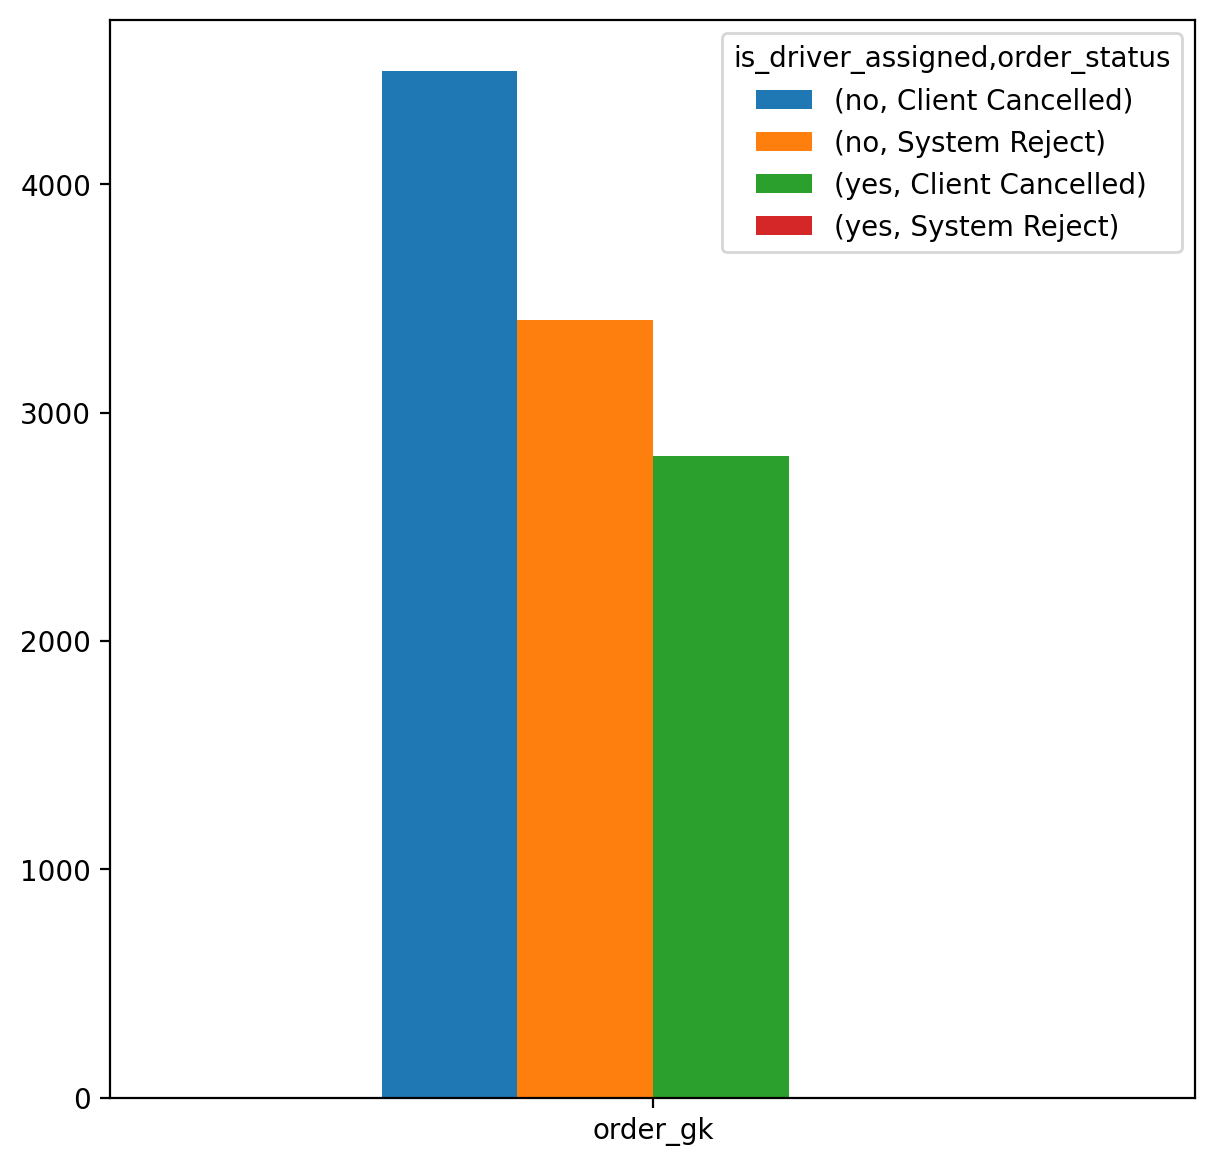

In [ ]:
rides_cancelled.plot(kind="bar", subplots=False, figsize=(7, 7), legend=True, rot=0)

#### majority of the cancellations are driven by the suppply issue, the company should focus on Aquiring drivers via referral etc programs

### during what time of the day, cancellations hits the roof?

#### extracting hour from time

In [ ]:
rides["order_hour"] = rides["order_time"].str.split(":").apply(lambda split: split[0])

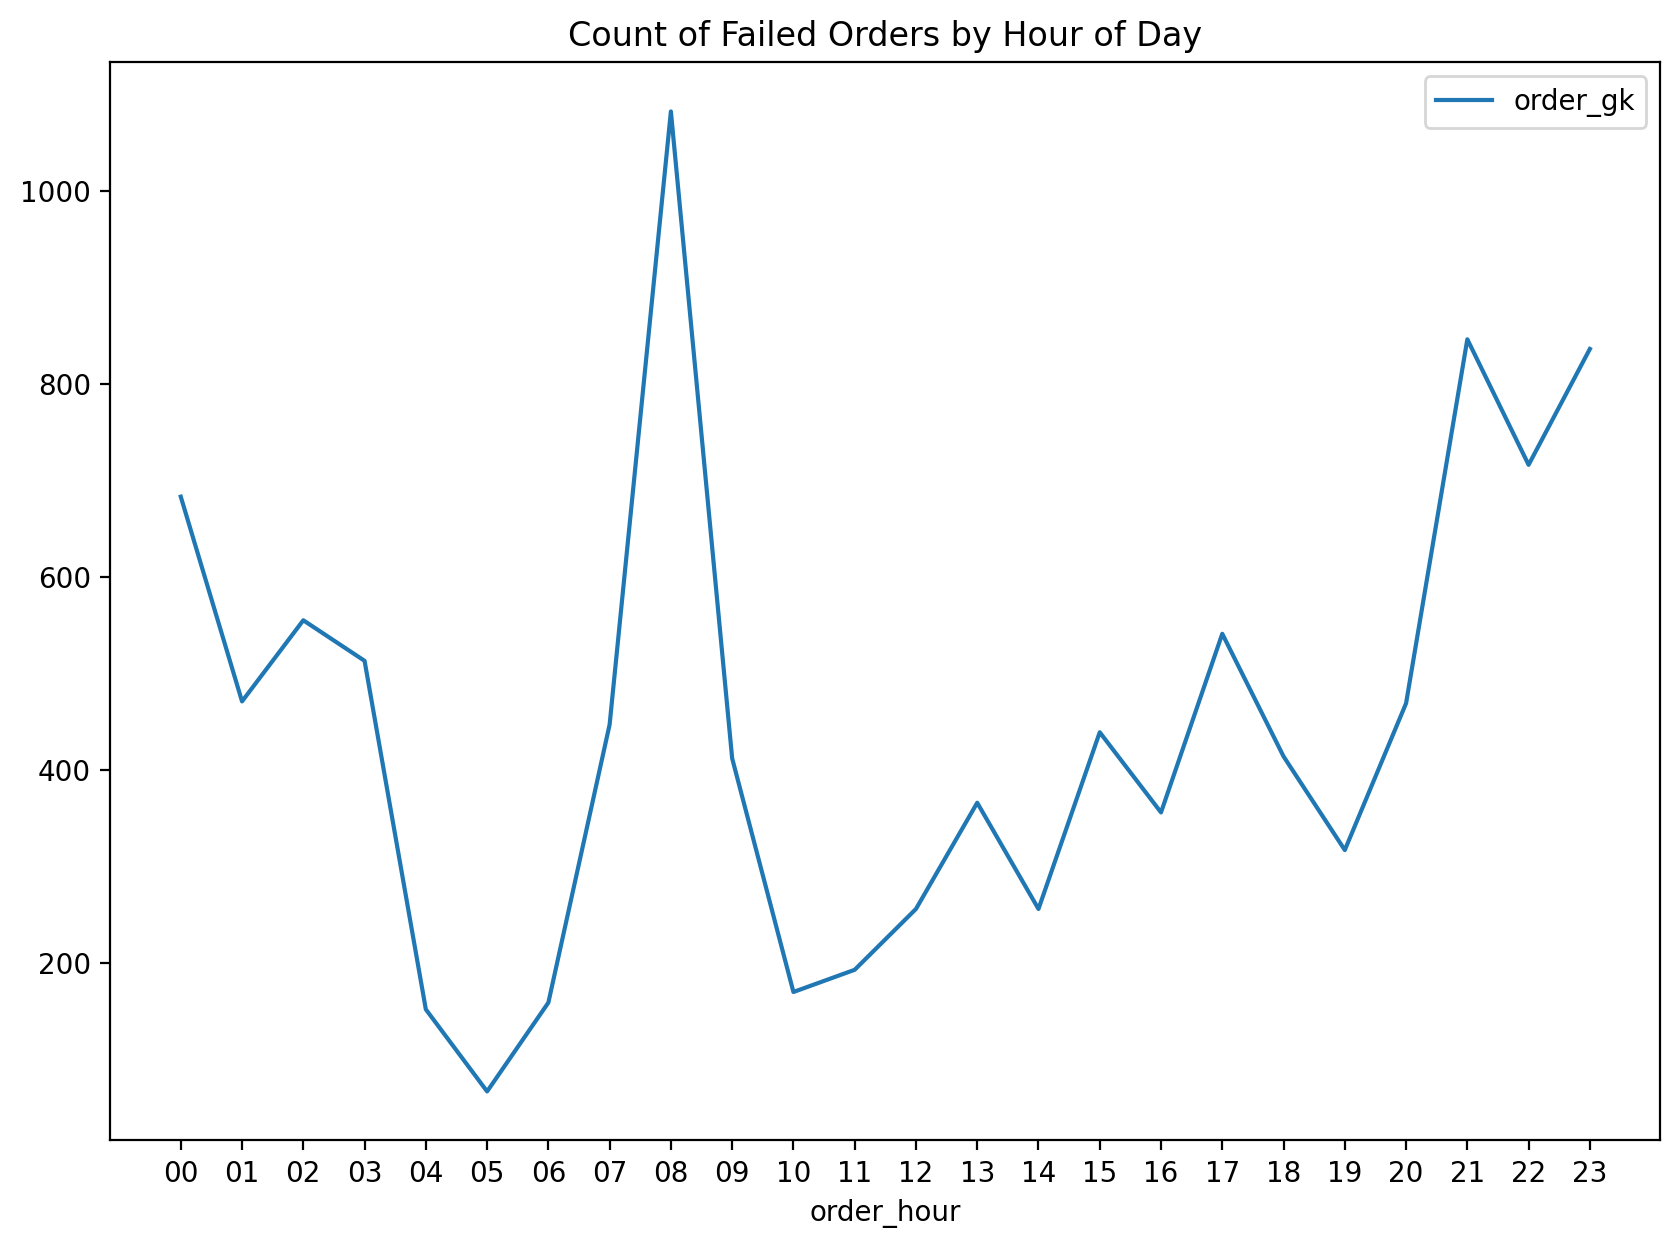

In [ ]:
rides.groupby("order_hour")["order_gk"].count().plot(figsize=(10, 7),
                                                         legend=True,
                                                         xticks=range(0, 24),
                                                         title="Count of Failed Orders by Hour of Day")

#### During office hours, maximum cancellations have occured and it grows after 7 pm sharply

### But what type of cancellations are driving in the office hours especially?

In [ ]:
hour_canellation_type=rides.pivot_table(index="order_hour",
                                   columns=["is_driver_assigned", "order_status"],
                                   values="order_gk",
                                   aggfunc="count").plot(xticks=range(0, 24),
                                                           figsize=(13, 7),
                                                           title="Count of Failed Orders Per Hour and Category")

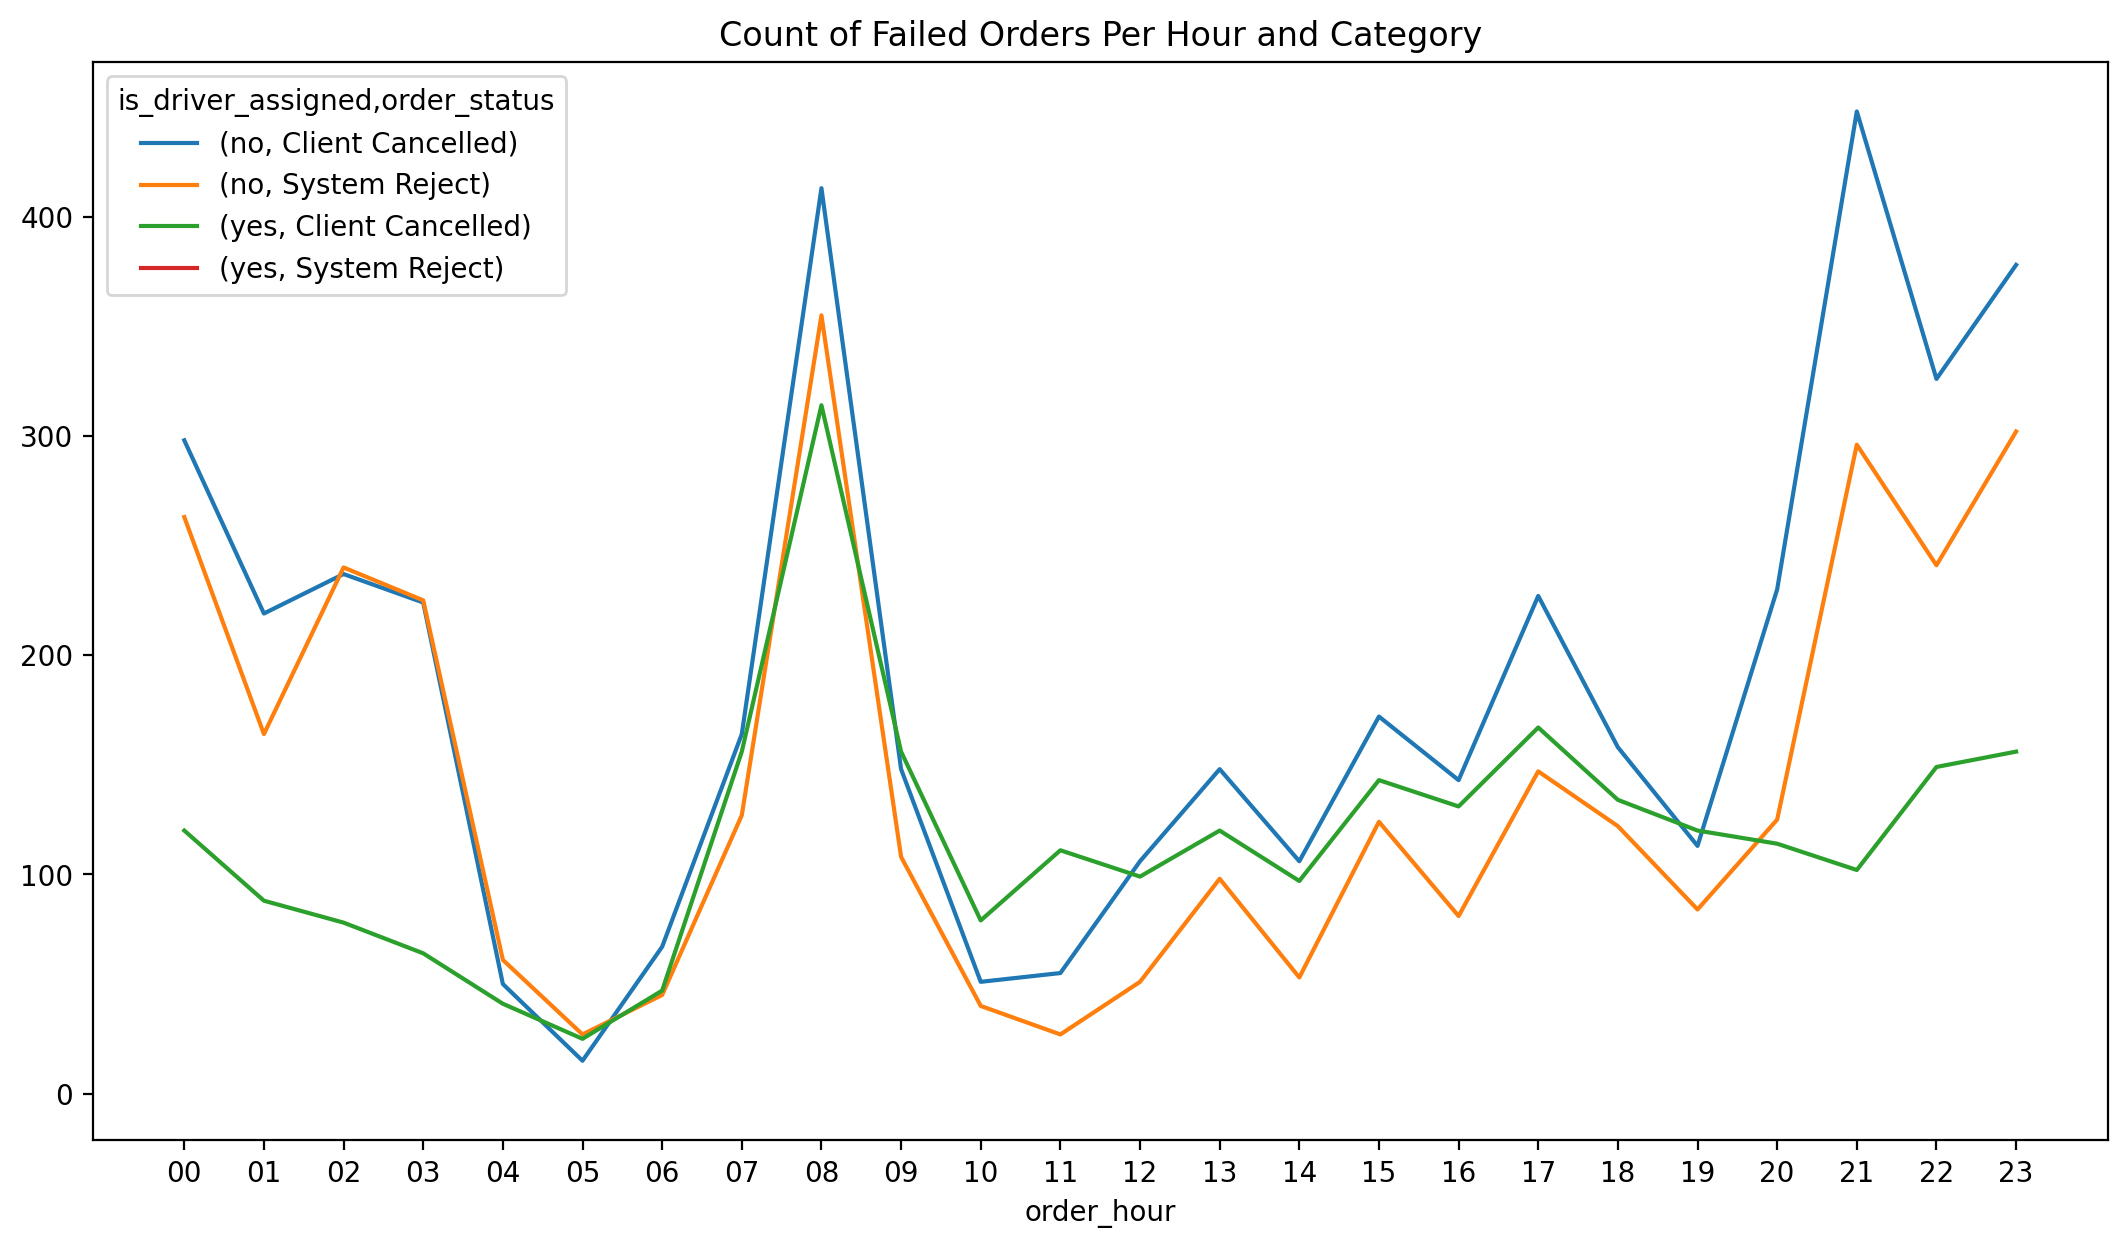

In [ ]:
hour_canellation_type

#### Majority of the cancellations of happening due to the non-assignment of drivers which indicated that there is a major supply-demand issue

### But why are the clients cancelling the rides after the asignment of drivers in the office hours, is it because of high ETA ?

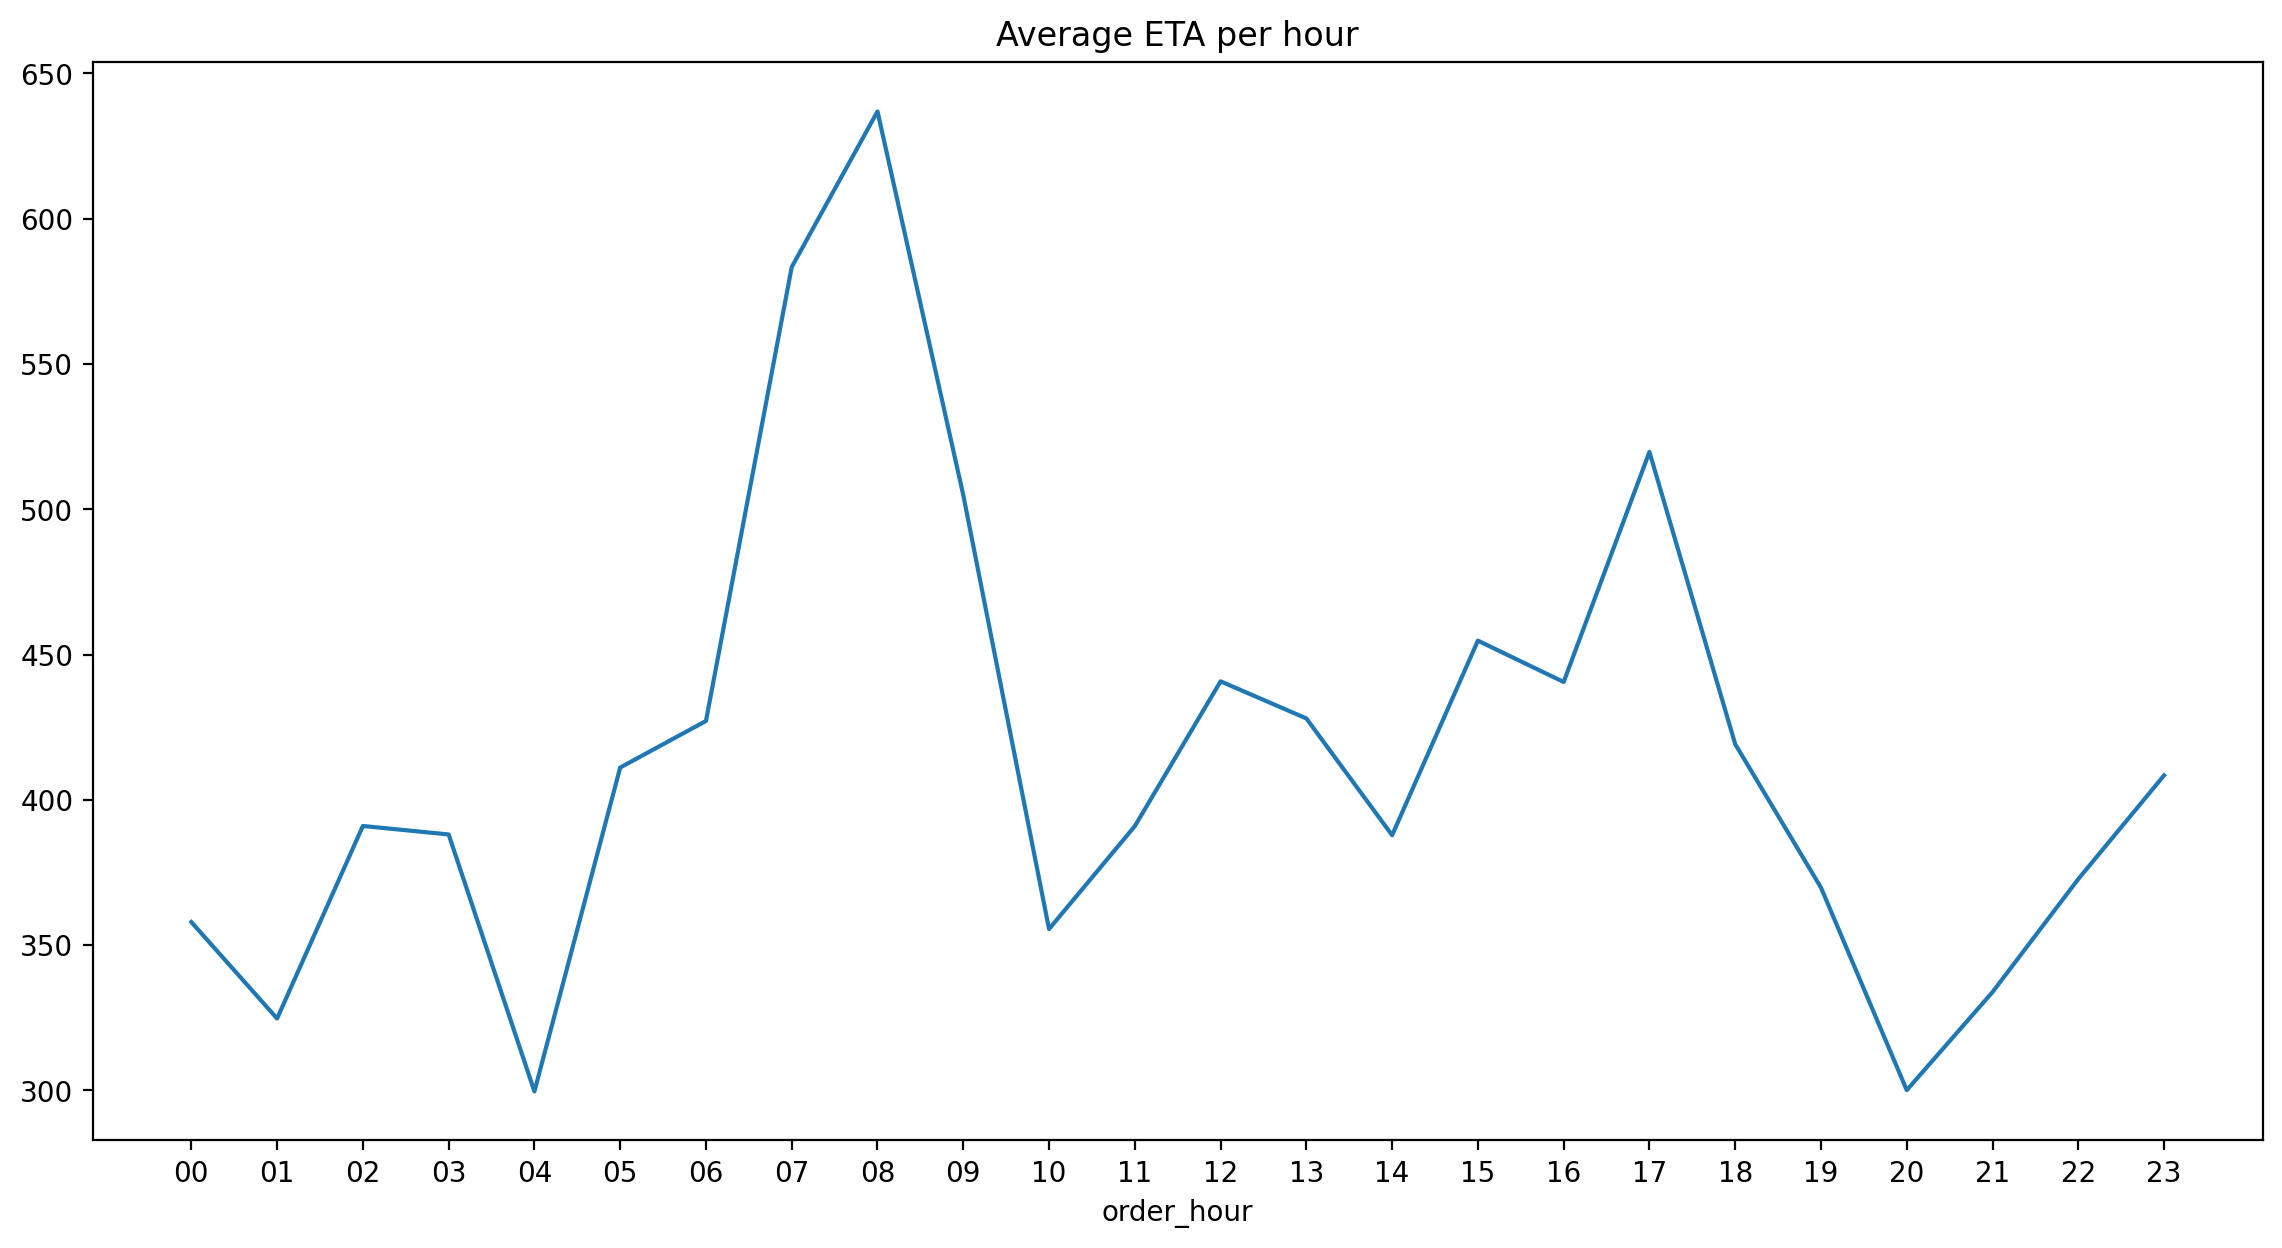

In [ ]:
rides.groupby("order_hour")["m_order_eta"].mean().plot(figsize=(14, 7),
                                                           xticks=range(0, 24),
                                                           title="Average ETA per hour")

#### In the office hours, the avg ETA is higher which is what the clients do not want, they want to get to the office as quickly as possible, let's check the time to cancellation for this to be proved

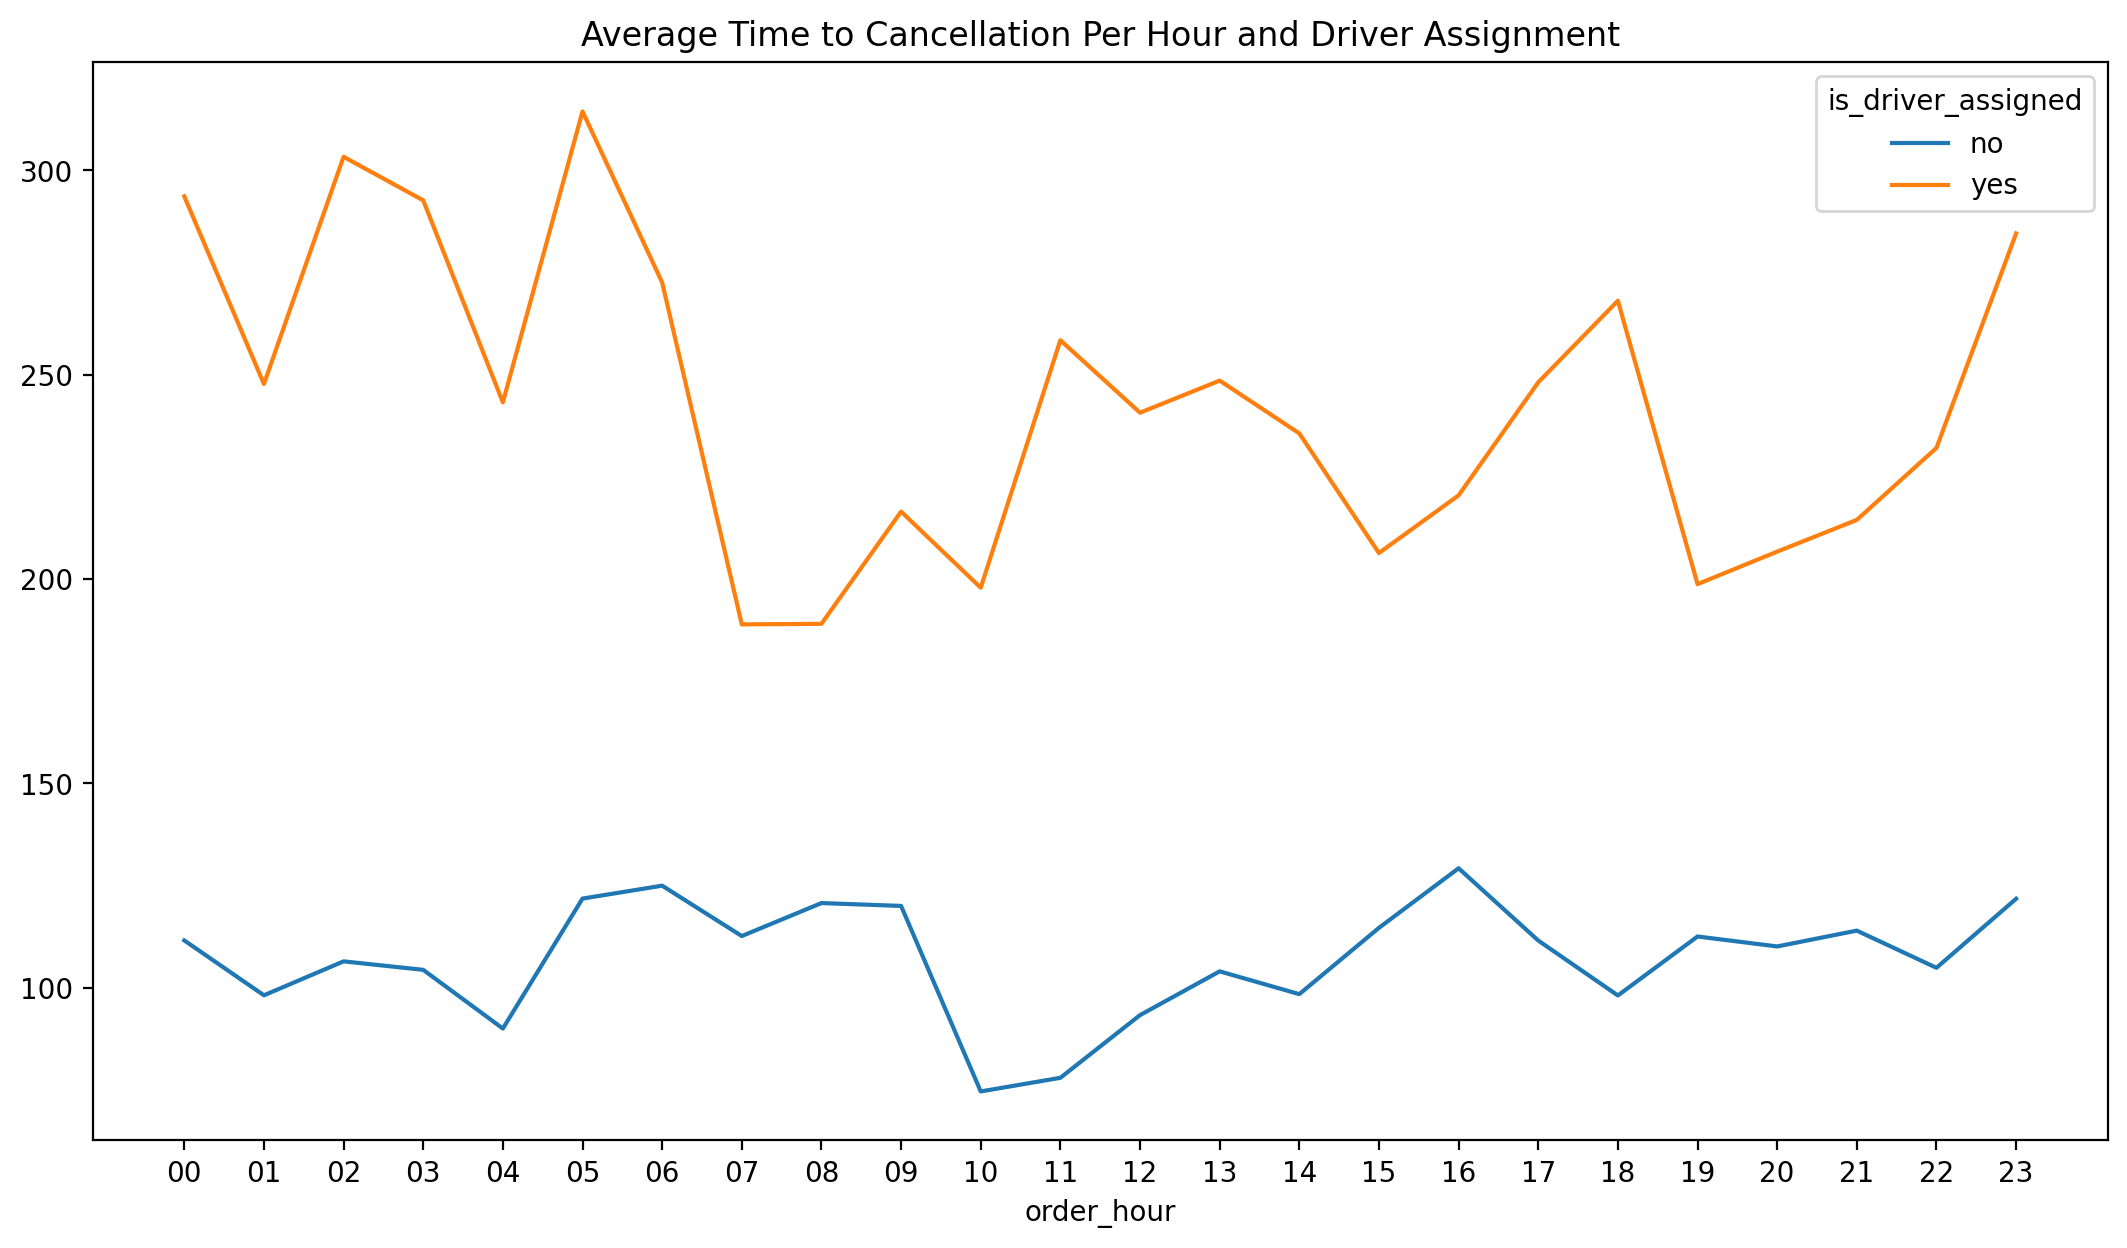

In [ ]:
rides.reset_index().pivot_table(index="order_hour",
                                   columns="is_driver_assigned",
                                   values="cancellations_time_in_seconds",
                                   aggfunc ="mean" ).plot(xticks=range(0, 24),
                                                                                figsize=(13, 7),
                                                                                title="Average Time to Cancellation Per Hour and Driver Assignment")

#### It is clear now,
- in office hours the avg ETA is the lowest for driver assigned rides, indicating that the clients want to reach the office or their destination in time, but we are not able to keep up to the demand due to supply issues.
- and can wait a bit more during the night hours and early in the morning, as their aim is to reach home safely.

## We would like to increase the supply, for this, Identifying the clusters/areas where the supply issue is more, using pareto analysis, we can identify the clusters where we need to prioritize  with increasing the supply

In [ ]:
import h3
import folium

#### converting lat-long into hexes

In [ ]:
rides["hex_id"] = rides.apply(
    func=lambda row: h3.latlng_to_cell(lat=row["origin_latitude"], lng=row["origin_longitude"], res=8), axis=1)
rides

<marimo-table data-initial-value='[]' data-label='null' data-data='"[{\"order_time\":\"18:08:07\",\"origin_longitude\":-0.978916,\"origin_latitude\":51.456173,\"m_order_eta\":60.0,\"order_gk\":3000583041974,\"cancellations_time_in_seconds\":198.0,\"is_driver_assigned\":\"yes\",\"order_status\":\"Client Cancelled\",\"order_hour\":\"18\",\"hex_id\":\"88195d2b03fffff\"},{\"order_time\":\"20:57:32\",\"origin_longitude\":-0.950385,\"origin_latitude\":51.456843,\"m_order_eta\":NaN,\"order_gk\":3000583116437,\"cancellations_time_in_seconds\":128.0,\"is_driver_assigned\":\"no\",\"order_status\":\"Client Cancelled\",\"order_hour\":\"20\",\"hex_id\":\"88195d2b19fffff\"},{\"order_time\":\"12:07:50\",\"origin_longitude\":-0.96952,\"origin_latitude\":51.455544,\"m_order_eta\":477.0,\"order_gk\":3000582891479,\"cancellations_time_in_seconds\":46.0,\"is_driver_assigned\":\"yes\",\"order_status\":\"Client Cancelled\",\"order_hour\":\"12\",\"hex_id\":\"88195d2b1dfffff\"},{\"order_time\":\"13:50:20\",\"origin_longitude\":-1.054671,\"origin_latitude\":51.460544,\"m_order_eta\":658.0,\"order_gk\":3000582941169,\"cancellations_time_in_seconds\":62.0,\"is_driver_assigned\":\"yes\",\"order_status\":\"Client Cancelled\",\"order_hour\":\"13\",\"hex_id\":\"88195d7497fffff\"},{\"order_time\":\"21:24:45\",\"origin_longitude\":-0.967605,\"origin_latitude\":51.458236,\"m_order_eta\":NaN,\"order_gk\":3000583140877,\"cancellations_time_in_seconds\":NaN,\"is_driver_assigned\":\"no\",\"order_status\":\"System Reject\",\"order_hour\":\"21\",\"hex_id\":\"88195d2b1dfffff\"},{\"order_time\":\"21:21:23\",\"origin_longitude\":-0.947011,\"origin_latitude\":51.45638,\"m_order_eta\":NaN,\"order_gk\":3000583117054,\"cancellations_time_in_seconds\":NaN,\"is_driver_assigned\":\"no\",\"order_status\":\"System Reject\",\"order_hour\":\"21\",\"hex_id\":\"88195d2a25fffff\"},{\"order_time\":\"07:58:15\",\"origin_longitude\":-0.955637,\"origin_latitude\":51.470372,\"m_order_eta\":NaN,\"order_gk\":3000582791789,\"cancellations_time_in_seconds\":NaN,\"is_driver_assigned\":\"no\",\"order_status\":\"System Reject\",\"order_hour\":\"07\",\"hex_id\":\"88195d2b51fffff\"},{\"order_time\":\"07:53:46\",\"origin_longitude\":-0.97823,\"origin_latitude\":51.454575,\"m_order_eta\":NaN,\"order_gk\":3000582791562,\"cancellations_time_in_seconds\":NaN,\"is_driver_assigned\":\"no\",\"order_status\":\"System Reject\",\"order_hour\":\"07\",\"hex_id\":\"88195d2b15fffff\"},{\"order_time\":\"08:53:01\",\"origin_longitude\":-1.052298,\"origin_latitude\":51.454308,\"m_order_eta\":NaN,\"order_gk\":3000582817606,\"cancellations_time_in_seconds\":NaN,\"is_driver_assigned\":\"no\",\"order_status\":\"System Reject\",\"order_hour\":\"08\",\"hex_id\":\"88195d2969fffff\"},{\"order_time\":\"06:33:52\",\"origin_longitude\":-0.976216,\"origin_latitude\":51.433202,\"m_order_eta\":NaN,\"order_gk\":3000582765616,\"cancellations_time_in_seconds\":78.0,\"is_driver_assigned\":\"no\",\"order_status\":\"Client Cancelled\",\"order_hour\":\"06\",\"hex_id\":\"88195d2861fffff\"}]"' data-total-rows='10716' data-total-columns='10' data-max-columns='50' data-banner-text='""' data-pagination='true' data-page-size='10' data-field-types='[["order_time",["string","str"]],["origin_longitude",["number","float64"]],["origin_latitude",["number","float64"]],["m_order_eta",["number","float64"]],["order_gk",["integer","int64"]],["cancellations_time_in_seconds",["number","float64"]],["is_driver_assigned",["string","str"]],["order_status",["string","str"]],["order_hour",["string","str"]],["hex_id",["string","str"]]]' data-show-filters='true' data-show-download='true' data-show-column-summaries='true' data-show-data-types='true' data-show-page-size-selector='true' data-show-column-explorer='true' data-show-chart-builder='true' data-row-headers='[]' data-has-stable-row-id='false' data-lazy='false' data-preload='false' data-download-file-name='"df"'>

#### first check which are the clusters where the demand is maximum?

To find the number of hexes that contain 80% of the orders, we will apply a cumulative percentage operation over the order_gk count column in the grouped_q5 DataFrame. This consists of the following steps:

- Sort the DataFrame by the count in decending order.
- Find the total number (sum) of failed orders.
- Apply the method cumsum to find the cumulative sum of the order-count column.
- Divide by the total sum to generate percentages.
- Filter to find the row that is closest to 80%.

how many cancellations have occured in every hex 8 ?

In [ ]:
demand_hex = rides.groupby("hex_id")["order_gk"].count()
demand_hex

<marimo-table data-initial-value='[]' data-label='null' data-data='"[{\"hex_id\":\"88195d2801fffff\",\"order_gk\":26},{\"hex_id\":\"88195d2803fffff\",\"order_gk\":11},{\"hex_id\":\"88195d2805fffff\",\"order_gk\":8},{\"hex_id\":\"88195d2807fffff\",\"order_gk\":1},{\"hex_id\":\"88195d2809fffff\",\"order_gk\":16},{\"hex_id\":\"88195d280bfffff\",\"order_gk\":7},{\"hex_id\":\"88195d280dfffff\",\"order_gk\":52},{\"hex_id\":\"88195d281dfffff\",\"order_gk\":1},{\"hex_id\":\"88195d2821fffff\",\"order_gk\":1},{\"hex_id\":\"88195d2823fffff\",\"order_gk\":7}]"' data-total-rows='144' data-total-columns='1' data-max-columns='50' data-banner-text='""' data-pagination='true' data-page-size='10' data-field-types='[["order_gk",["integer","int64"]]]' data-show-filters='true' data-show-download='true' data-show-column-summaries='true' data-show-data-types='true' data-show-page-size-selector='true' data-show-column-explorer='true' data-show-chart-builder='true' data-row-headers='[["hex_id",["string","str"]]]' data-has-stable-row-id='false' data-lazy='false' data-preload='false' data-download-file-name='"download"'>

In [ ]:
hex_rides = demand_hex.reset_index().sort_values(by="order_gk",ascending=False)  # 1
total_orders = hex_rides["order_gk"].sum()  # 2
hex_rides["cum_sum"] = hex_rides["order_gk"].cumsum()  # 3
hex_rides["cum_perc"] = 100 * hex_rides["cum_sum"] / total_orders  # 4
hex_rides[hex_rides["cum_perc"] <= 80]  # 5

<marimo-table data-initial-value='[]' data-label='null' data-data='"[{\"\":97,\"hex_id\":\"88195d2b1dfffff\",\"order_gk\":1497,\"cum_sum\":1497,\"cum_perc\":13.96976483762598},{\"\":96,\"hex_id\":\"88195d2b1bfffff\",\"order_gk\":870,\"cum_sum\":2367,\"cum_perc\":22.088465845464725},{\"\":93,\"hex_id\":\"88195d2b15fffff\",\"order_gk\":774,\"cum_sum\":3141,\"cum_perc\":29.31131019036954},{\"\":91,\"hex_id\":\"88195d2b11fffff\",\"order_gk\":707,\"cum_sum\":3848,\"cum_perc\":35.90892123926838},{\"\":95,\"hex_id\":\"88195d2b19fffff\",\"order_gk\":667,\"cum_sum\":4515,\"cum_perc\":42.13325867861142},{\"\":20,\"hex_id\":\"88195d284dfffff\",\"order_gk\":653,\"cum_sum\":5168,\"cum_perc\":48.226950354609926},{\"\":63,\"hex_id\":\"88195d2a27fffff\",\"order_gk\":414,\"cum_sum\":5582,\"cum_perc\":52.090332213512504},{\"\":89,\"hex_id\":\"88195d2b0bfffff\",\"order_gk\":372,\"cum_sum\":5954,\"cum_perc\":55.561776782381486},{\"\":62,\"hex_id\":\"88195d2a25fffff\",\"order_gk\":362,\"cum_sum\":6316,\"cum_perc\":58.939902948861516},{\"\":92,\"hex_id\":\"88195d2b13fffff\",\"order_gk\":346,\"cum_sum\":6662,\"cum_perc\":62.16871967151922}]"' data-total-rows='23' data-total-columns='4' data-max-columns='50' data-banner-text='""' data-pagination='true' data-page-size='10' data-field-types='[["hex_id",["string","str"]],["order_gk",["integer","int64"]],["cum_sum",["integer","int64"]],["cum_perc",["number","float64"]]]' data-show-filters='true' data-show-download='true' data-show-column-summaries='true' data-show-data-types='true' data-show-page-size-selector='true' data-show-column-explorer='true' data-show-chart-builder='true' data-row-headers='[["",["integer","int64"]]]' data-has-stable-row-id='false' data-lazy='false' data-preload='false' data-download-file-name='"df"'>

In [ ]:
map = folium.Map(location=[rides["origin_latitude"].mean(), rides["origin_longitude"].mean()],
                 zoom_start=8.5,  # after a bit of experimentation, we thought this presents the map best
                 tiles="cartodbpositron")

In [ ]:
import json
import geojson
from h3.api import basic_int as h3_api  # renamed to avoid redefinition error

def to_geojson(row):
    int_cell = int(row["hex_id"], 16)
    latlngs = h3_api.cell_to_boundary(int_cell)
    lnglats = [[lng, lat] for lat, lng in latlngs]

    geometry = {"type": "Polygon", "coordinates": [lnglats]}
    return geojson.Feature(
        id=row["hex_id"],
        geometry=geometry,
        properties={"order_gk": row["order_gk"]}
    )

geojsons = hex_rides.apply(to_geojson, axis=1).tolist()
geojson_str = json.dumps(geojson.FeatureCollection(geojsons))

In [ ]:
import matplotlib

colormap = matplotlib.colormaps["plasma"]  # 
max_order_gk = hex_rides["order_gk"].max()
min_order_gk = hex_rides["order_gk"].min()

In [ ]:
folium.GeoJson(data=geojson_str, style_function=lambda f: {
    "fillColor": matplotlib.colors.to_hex(
        colormap((f["properties"]["order_gk"] - min_order_gk) / (max_order_gk - min_order_gk))),
    "color": "black",
    "weight": 1,
    "fillOpacity": 0.7
}).add_to(map)

<folium.features.GeoJson object at 0x7f4a889415b0>

In [ ]:
map

Make this Notebook Trusted to load map: File -> Trust Notebook <iframe srcdoc="<!DOCTYPE html>
<html>
<head>
 
 <meta http-equiv="content-type" content="text/html; charset=UTF-8" />
 <script src="https://cdn.jsdelivr.net/npm/leaflet@1.9.3/dist/leaflet.js"></script>
 <script src="https://code.jquery.com/jquery-3.7.1.min.js"></script>
 <script src="https://cdn.jsdelivr.net/npm/bootstrap@5.2.2/dist/js/bootstrap.bundle.min.js"></script>
 <script src="https://cdnjs.cloudflare.com/ajax/libs/Leaflet.awesome-markers/2.0.2/leaflet.awesome-markers.js"></script>
 <link rel="stylesheet" href="https://cdn.jsdelivr.net/npm/leaflet@1.9.3/dist/leaflet.css"/>
 <link rel="stylesheet" href="https://cdn.jsdelivr.net/npm/bootstrap@5.2.2/dist/css/bootstrap.min.css"/>
 <link rel="stylesheet" href="https://netdna.bootstrapcdn.com/bootstrap/3.0.0/css/bootstrap-glyphicons.css"/>
 <link rel="stylesheet" href="https://cdn.jsdelivr.net/npm/@fortawesome/fontawesome-free@6.2.0/css/all.min.css"/>
 <link rel="stylesheet" href="https://cdnjs.cloudflare.com/ajax/libs/Leaflet.awesome-markers/2.0.2/leaflet.awesome-markers.css"/>
 <link rel="stylesheet" href="https://cdn.jsdelivr.net/gh/python-visualization/folium/folium/templates/leaflet.awesome.rotate.min.css"/>
 
 <meta name="viewport" content="width=device-width,
 initial-scale=1.0, maximum-scale=1.0, user-scalable=no" />
 <style>
 #map_d4f33c97987a87255f7e145d4222a1db {
 position: relative;
 width: 100.0%;
 height: 100.0%;
 left: 0.0%;
 top: 0.0%;
 }
 .leaflet-container { font-size: 1rem; }
 </style>

 <style>html, body {
 width: 100%;
 height: 100%;
 margin: 0;
 padding: 0;
 }
 </style>

 <style>#map {
 position:absolute;
 top:0;
 bottom:0;
 right:0;
 left:0;
 }
 </style>

 <script>
 L_NO_TOUCH = false;
 L_DISABLE_3D = false;
 </script>

 
</head>
<body>
 
 
 <div class="folium-map" id="map_d4f33c97987a87255f7e145d4222a1db" ></div>
 
</body>
<script>
 
 
 var map_d4f33c97987a87255f7e145d4222a1db = L.map(
 "map_d4f33c97987a87255f7e145d4222a1db",
 {
 center: [51.45054119578201, -0.9643232313363195],
 crs: L.CRS.EPSG3857,
 ...{
 "zoom": 8.5,
 "zoomControl": true,
 "preferCanvas": false,
}

 }
 );

 

 
 
 var tile_layer_66d8a21f5cd5d1bab815b8407e3613e9 = L.tileLayer(
 "https://{s}.basemaps.cartocdn.com/light_all/{z}/{x}/{y}{r}.png",
 {
 "minZoom": 0,
 "maxZoom": 20,
 "maxNativeZoom": 20,
 "noWrap": false,
 "attribution": "\u0026copy; \u003ca href=\"https://www.openstreetmap.org/copyright\"\u003eOpenStreetMap\u003c/a\u003e contributors \u0026copy; \u003ca href=\"https://carto.com/attributions\"\u003eCARTO\u003c/a\u003e",
 "subdomains": "abcd",
 "detectRetina": false,
 "tms": false,
 "opacity": 1,
}

 );
 
 
 tile_layer_66d8a21f5cd5d1bab815b8407e3613e9.addTo(map_d4f33c97987a87255f7e145d4222a1db);
 
 
 function geo_json_c0f4094fae5aef8f54fe1c4c51f92907_styler(feature) {
 switch(feature.id) {
 case "88195d2b1dfffff": 
 return {"color": "black", "fillColor": "#f0f921", "fillOpacity": 0.7, "weight": 1};
 case "88195d2b1bfffff": 
 return {"color": "black", "fillColor": "#dd5e66", "fillOpacity": 0.7, "weight": 1};
 case "88195d2b15fffff": 
 return {"color": "black", "fillColor": "#cf4c74", "fillOpacity": 0.7, "weight": 1};
 case "88195d2b11fffff": 
 return {"color": "black", "fillColor": "#c43e7f", "fillOpacity": 0.7, "weight": 1};
 case "88195d2b19fffff": 
 return {"color": "black", "fillColor": "#bd3786", "fillOpacity": 0.7, "weight": 1};
 case "88195d284dfffff": 
 return {"color": "black", "fillColor": "#bb3488", "fillOpacity": 0.7, "weight": 1};
 case "88195d2a27fffff": 
 return {"color": "black", "fillColor": "#8707a6", "fillOpacity": 0.7, "weight": 1};
 case "88195d2b0bfffff": 
 return {"color": "black", "fillColor": "#7d03a8", "fillOpacity": 0.7, "weight": 1};
 case "88195d2a25fffff": 
 return {"color": "black", "fillColor": "#7a02a8", "fillOpacity": 0.7, "weight": 1};
 case "88195d2b13fffff": 
 return {"color": "black", "fillColor": "#7701a8", "fillOpacity": 0.7, "weight": 1};
 case "88195d2b03fffff": 
 return 

#### The brighter ones are the clusters where the maximum number of cancellations of rides have occured and vice versa is present which we can clearly see is at the centre of the city

## Now, which are ones where maximum cancellations have happened due to the non-assignment of captains

In [ ]:
cancellation_hex = rides[
    (rides["is_driver_assigned"] == "no") &
    (rides["order_status"] == "Client Cancelled")
].groupby("hex_id")["order_gk"].count()
cancellation_hex

<marimo-table data-initial-value='[]' data-label='null' data-data='"[{\"hex_id\":\"88195d2801fffff\",\"order_gk\":14},{\"hex_id\":\"88195d2803fffff\",\"order_gk\":6},{\"hex_id\":\"88195d2805fffff\",\"order_gk\":5},{\"hex_id\":\"88195d2807fffff\",\"order_gk\":1},{\"hex_id\":\"88195d2809fffff\",\"order_gk\":7},{\"hex_id\":\"88195d280bfffff\",\"order_gk\":3},{\"hex_id\":\"88195d280dfffff\",\"order_gk\":15},{\"hex_id\":\"88195d2823fffff\",\"order_gk\":1},{\"hex_id\":\"88195d2829fffff\",\"order_gk\":15},{\"hex_id\":\"88195d282bfffff\",\"order_gk\":3}]"' data-total-rows='132' data-total-columns='1' data-max-columns='50' data-banner-text='""' data-pagination='true' data-page-size='10' data-field-types='[["order_gk",["integer","int64"]]]' data-show-filters='true' data-show-download='true' data-show-column-summaries='true' data-show-data-types='true' data-show-page-size-selector='true' data-show-column-explorer='true' data-show-chart-builder='true' data-row-headers='[["hex_id",["string","str"]]]' data-has-stable-row-id='false' data-lazy='false' data-preload='false' data-download-file-name='"download"'>

In [ ]:
cancellation_hex_rides = (
    cancellation_hex
    .reset_index()
    .sort_values(by="order_gk", ascending=False)
)

total_cancelled_orders = cancellation_hex_rides["order_gk"].sum()

cancellation_hex_rides["cum_sum"] = (
    cancellation_hex_rides["order_gk"].cumsum()
)

cancellation_hex_rides["cum_perc"] = (
    100 * cancellation_hex_rides["cum_sum"]
    / total_cancelled_orders
)

pareto_80 = cancellation_hex_rides[
    cancellation_hex_rides["cum_perc"] <= 80
]

pareto_80

<marimo-table data-initial-value='[]' data-label='null' data-data='"[{\"\":91,\"hex_id\":\"88195d2b1dfffff\",\"order_gk\":724,\"cum_sum\":724,\"cum_perc\":16.10320284697509},{\"\":90,\"hex_id\":\"88195d2b1bfffff\",\"order_gk\":364,\"cum_sum\":1088,\"cum_perc\":24.199288256227756},{\"\":87,\"hex_id\":\"88195d2b15fffff\",\"order_gk\":336,\"cum_sum\":1424,\"cum_perc\":31.672597864768683},{\"\":85,\"hex_id\":\"88195d2b11fffff\",\"order_gk\":292,\"cum_sum\":1716,\"cum_perc\":38.16725978647687},{\"\":18,\"hex_id\":\"88195d284dfffff\",\"order_gk\":264,\"cum_sum\":1980,\"cum_perc\":44.03914590747331},{\"\":89,\"hex_id\":\"88195d2b19fffff\",\"order_gk\":252,\"cum_sum\":2232,\"cum_perc\":49.644128113879006},{\"\":59,\"hex_id\":\"88195d2a25fffff\",\"order_gk\":166,\"cum_sum\":2398,\"cum_perc\":53.336298932384345},{\"\":60,\"hex_id\":\"88195d2a27fffff\",\"order_gk\":153,\"cum_sum\":2551,\"cum_perc\":56.73932384341637},{\"\":83,\"hex_id\":\"88195d2b0bfffff\",\"order_gk\":153,\"cum_sum\":2704,\"cum_perc\":60.1423487544484},{\"\":86,\"hex_id\":\"88195d2b13fffff\",\"order_gk\":148,\"cum_sum\":2852,\"cum_perc\":63.43416370106762}]"' data-total-rows='22' data-total-columns='4' data-max-columns='50' data-banner-text='""' data-pagination='true' data-page-size='10' data-field-types='[["hex_id",["string","str"]],["order_gk",["integer","int64"]],["cum_sum",["integer","int64"]],["cum_perc",["number","float64"]]]' data-show-filters='true' data-show-download='true' data-show-column-summaries='true' data-show-data-types='true' data-show-page-size-selector='true' data-show-column-explorer='true' data-show-chart-builder='true' data-row-headers='[["",["integer","int64"]]]' data-has-stable-row-id='false' data-lazy='false' data-preload='false' data-download-file-name='"df"'>

In [ ]:
def _():
    import json
    import geojson
    from h3.api import basic_int as h3_api  # renamed to avoid redefinition error

    def to_geojson(row):
        int_cell = int(row["hex_id"], 16)
        latlngs = h3_api.cell_to_boundary(int_cell)
        lnglats = [[lng, lat] for lat, lng in latlngs]

        geometry = {"type": "Polygon", "coordinates": [lnglats]}
        return geojson.Feature(
            id=row["hex_id"],
            geometry=geometry,
            properties={"order_gk": row["order_gk"]}
        )

    geojsons_new = cancellation_hex_rides.apply(to_geojson, axis=1).tolist()
    geojson_str_new = json.dumps(geojson.FeatureCollection(geojsons))
    return


_()

In [ ]:



max_order_gk_can = cancellation_hex_rides["order_gk"].max()
min_order_gk_can = cancellation_hex_rides["order_gk"].min()

In [ ]:
folium.GeoJson(data=geojson_str, style_function=lambda f: {
    "fillColor": matplotlib.colors.to_hex(
        colormap((f["properties"]["order_gk"] - min_order_gk_can) / (max_order_gk_can - min_order_gk_can))),
    "color": "black",
    "weight": 1,
    "fillOpacity": 0.7
}).add_to(map)

<folium.features.GeoJson object at 0x7f4a83791220>

In [ ]:
map

Make this Notebook Trusted to load map: File -> Trust Notebook <iframe srcdoc="<!DOCTYPE html>
<html>
<head>
 
 <meta http-equiv="content-type" content="text/html; charset=UTF-8" />
 <script src="https://cdn.jsdelivr.net/npm/leaflet@1.9.3/dist/leaflet.js"></script>
 <script src="https://code.jquery.com/jquery-3.7.1.min.js"></script>
 <script src="https://cdn.jsdelivr.net/npm/bootstrap@5.2.2/dist/js/bootstrap.bundle.min.js"></script>
 <script src="https://cdnjs.cloudflare.com/ajax/libs/Leaflet.awesome-markers/2.0.2/leaflet.awesome-markers.js"></script>
 <link rel="stylesheet" href="https://cdn.jsdelivr.net/npm/leaflet@1.9.3/dist/leaflet.css"/>
 <link rel="stylesheet" href="https://cdn.jsdelivr.net/npm/bootstrap@5.2.2/dist/css/bootstrap.min.css"/>
 <link rel="stylesheet" href="https://netdna.bootstrapcdn.com/bootstrap/3.0.0/css/bootstrap-glyphicons.css"/>
 <link rel="stylesheet" href="https://cdn.jsdelivr.net/npm/@fortawesome/fontawesome-free@6.2.0/css/all.min.css"/>
 <link rel="stylesheet" href="https://cdnjs.cloudflare.com/ajax/libs/Leaflet.awesome-markers/2.0.2/leaflet.awesome-markers.css"/>
 <link rel="stylesheet" href="https://cdn.jsdelivr.net/gh/python-visualization/folium/folium/templates/leaflet.awesome.rotate.min.css"/>
 
 <meta name="viewport" content="width=device-width,
 initial-scale=1.0, maximum-scale=1.0, user-scalable=no" />
 <style>
 #map_d4f33c97987a87255f7e145d4222a1db {
 position: relative;
 width: 100.0%;
 height: 100.0%;
 left: 0.0%;
 top: 0.0%;
 }
 .leaflet-container { font-size: 1rem; }
 </style>

 <style>html, body {
 width: 100%;
 height: 100%;
 margin: 0;
 padding: 0;
 }
 </style>

 <style>#map {
 position:absolute;
 top:0;
 bottom:0;
 right:0;
 left:0;
 }
 </style>

 <script>
 L_NO_TOUCH = false;
 L_DISABLE_3D = false;
 </script>

 
</head>
<body>
 
 
 <div class="folium-map" id="map_d4f33c97987a87255f7e145d4222a1db" ></div>
 
</body>
<script>
 
 
 var map_d4f33c97987a87255f7e145d4222a1db = L.map(
 "map_d4f33c97987a87255f7e145d4222a1db",
 {
 center: [51.45054119578201, -0.9643232313363195],
 crs: L.CRS.EPSG3857,
 ...{
 "zoom": 8.5,
 "zoomControl": true,
 "preferCanvas": false,
}

 }
 );

 

 
 
 var tile_layer_66d8a21f5cd5d1bab815b8407e3613e9 = L.tileLayer(
 "https://{s}.basemaps.cartocdn.com/light_all/{z}/{x}/{y}{r}.png",
 {
 "minZoom": 0,
 "maxZoom": 20,
 "maxNativeZoom": 20,
 "noWrap": false,
 "attribution": "\u0026copy; \u003ca href=\"https://www.openstreetmap.org/copyright\"\u003eOpenStreetMap\u003c/a\u003e contributors \u0026copy; \u003ca href=\"https://carto.com/attributions\"\u003eCARTO\u003c/a\u003e",
 "subdomains": "abcd",
 "detectRetina": false,
 "tms": false,
 "opacity": 1,
}

 );
 
 
 tile_layer_66d8a21f5cd5d1bab815b8407e3613e9.addTo(map_d4f33c97987a87255f7e145d4222a1db);
 
 
 function geo_json_c0f4094fae5aef8f54fe1c4c51f92907_styler(feature) {
 switch(feature.id) {
 case "88195d2b1dfffff": 
 return {"color": "black", "fillColor": "#f0f921", "fillOpacity": 0.7, "weight": 1};
 case "88195d2b1bfffff": 
 return {"color": "black", "fillColor": "#dd5e66", "fillOpacity": 0.7, "weight": 1};
 case "88195d2b15fffff": 
 return {"color": "black", "fillColor": "#cf4c74", "fillOpacity": 0.7, "weight": 1};
 case "88195d2b11fffff": 
 return {"color": "black", "fillColor": "#c43e7f", "fillOpacity": 0.7, "weight": 1};
 case "88195d2b19fffff": 
 return {"color": "black", "fillColor": "#bd3786", "fillOpacity": 0.7, "weight": 1};
 case "88195d284dfffff": 
 return {"color": "black", "fillColor": "#bb3488", "fillOpacity": 0.7, "weight": 1};
 case "88195d2a27fffff": 
 return {"color": "black", "fillColor": "#8707a6", "fillOpacity": 0.7, "weight": 1};
 case "88195d2b0bfffff": 
 return {"color": "black", "fillColor": "#7d03a8", "fillOpacity": 0.7, "weight": 1};
 case "88195d2a25fffff": 
 return {"color": "black", "fillColor": "#7a02a8", "fillOpacity": 0.7, "weight": 1};
 case "88195d2b13fffff": 
 return {"color": "black", "fillColor": "#7701a8", "fillOpacity": 0.7, "weight": 1};
 case "88195d2b03fffff": 
 return 

these are the areas/clusters where we need to focus on to improve our supply of drivers to match the demand, also where the drivers have been assigned, we have seen, the orders have high avg ETA,
-- to reduce the ETA, the follwing measures can be taken
- onboard more drivers in these clusters
- Enable users/customers to walk to a certain location near the pickup, which would make them save some money and also be able to get the ride quickly